In [1]:
import numpy as np
from getdist import plots, MCSamples
import corner
import matplotlib.pyplot as pl
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
pl.rc('text', usetex=False)
pl.rc('font', family='DejaVu Sans')
pl.rc('font', size='14')
colours = ['#348ABD', '#A60628', '#7A68A6', '#467821', '#D55E00', '#CC79A7', '#56B4E9', '#009E73', '#F0E442', '#0072B2']
pl.style.use('bmh')
pl.rcParams.update({'axes.facecolor': 'white',
                    'axes.edgecolor': 'black'})

In [2]:
chain = np.load('/Users/austerlitz/TripoSH-Factory/my_project/debug/results/LRG/p0p2b0b2_finalemu.npy',allow_pickle=True).item()

In [13]:
names = ['omega_cdm',
  'omega_b',
  'h',
  'n_s',
  'ln10^{10}A_s',
  'b1',
  'b2',
  'bG2',
  'bGamma3',
  'c0', 
  'c2pp',
  'ch',
  'c1',
  'c2',
  'Pshot',
  'a0',
  'Bshot']

labels = [r'\omega_{\rm cdm}',
 r'\omega_b',
 r'h',
 r'n_s',
 r'\ln10^{10}A_s',
 r'b_1',
 r'b_2',
 r'b_{{\cal G}_2}',
 r'b_{\Gamma_3}',
 r'c_0',
 r'c_2^{pp}',
 r'c_h',
 r'c_1',
 r'c_2',
 r'P_{\rm shot}', 
 r'a_0',
 r'B_{\rm shot}']

In [14]:
fiducial = [0.12,
 0.022,
 0.67,
 0.9649,
 3.036,
 2,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0, 
 0,
 0]

Removed no burn in


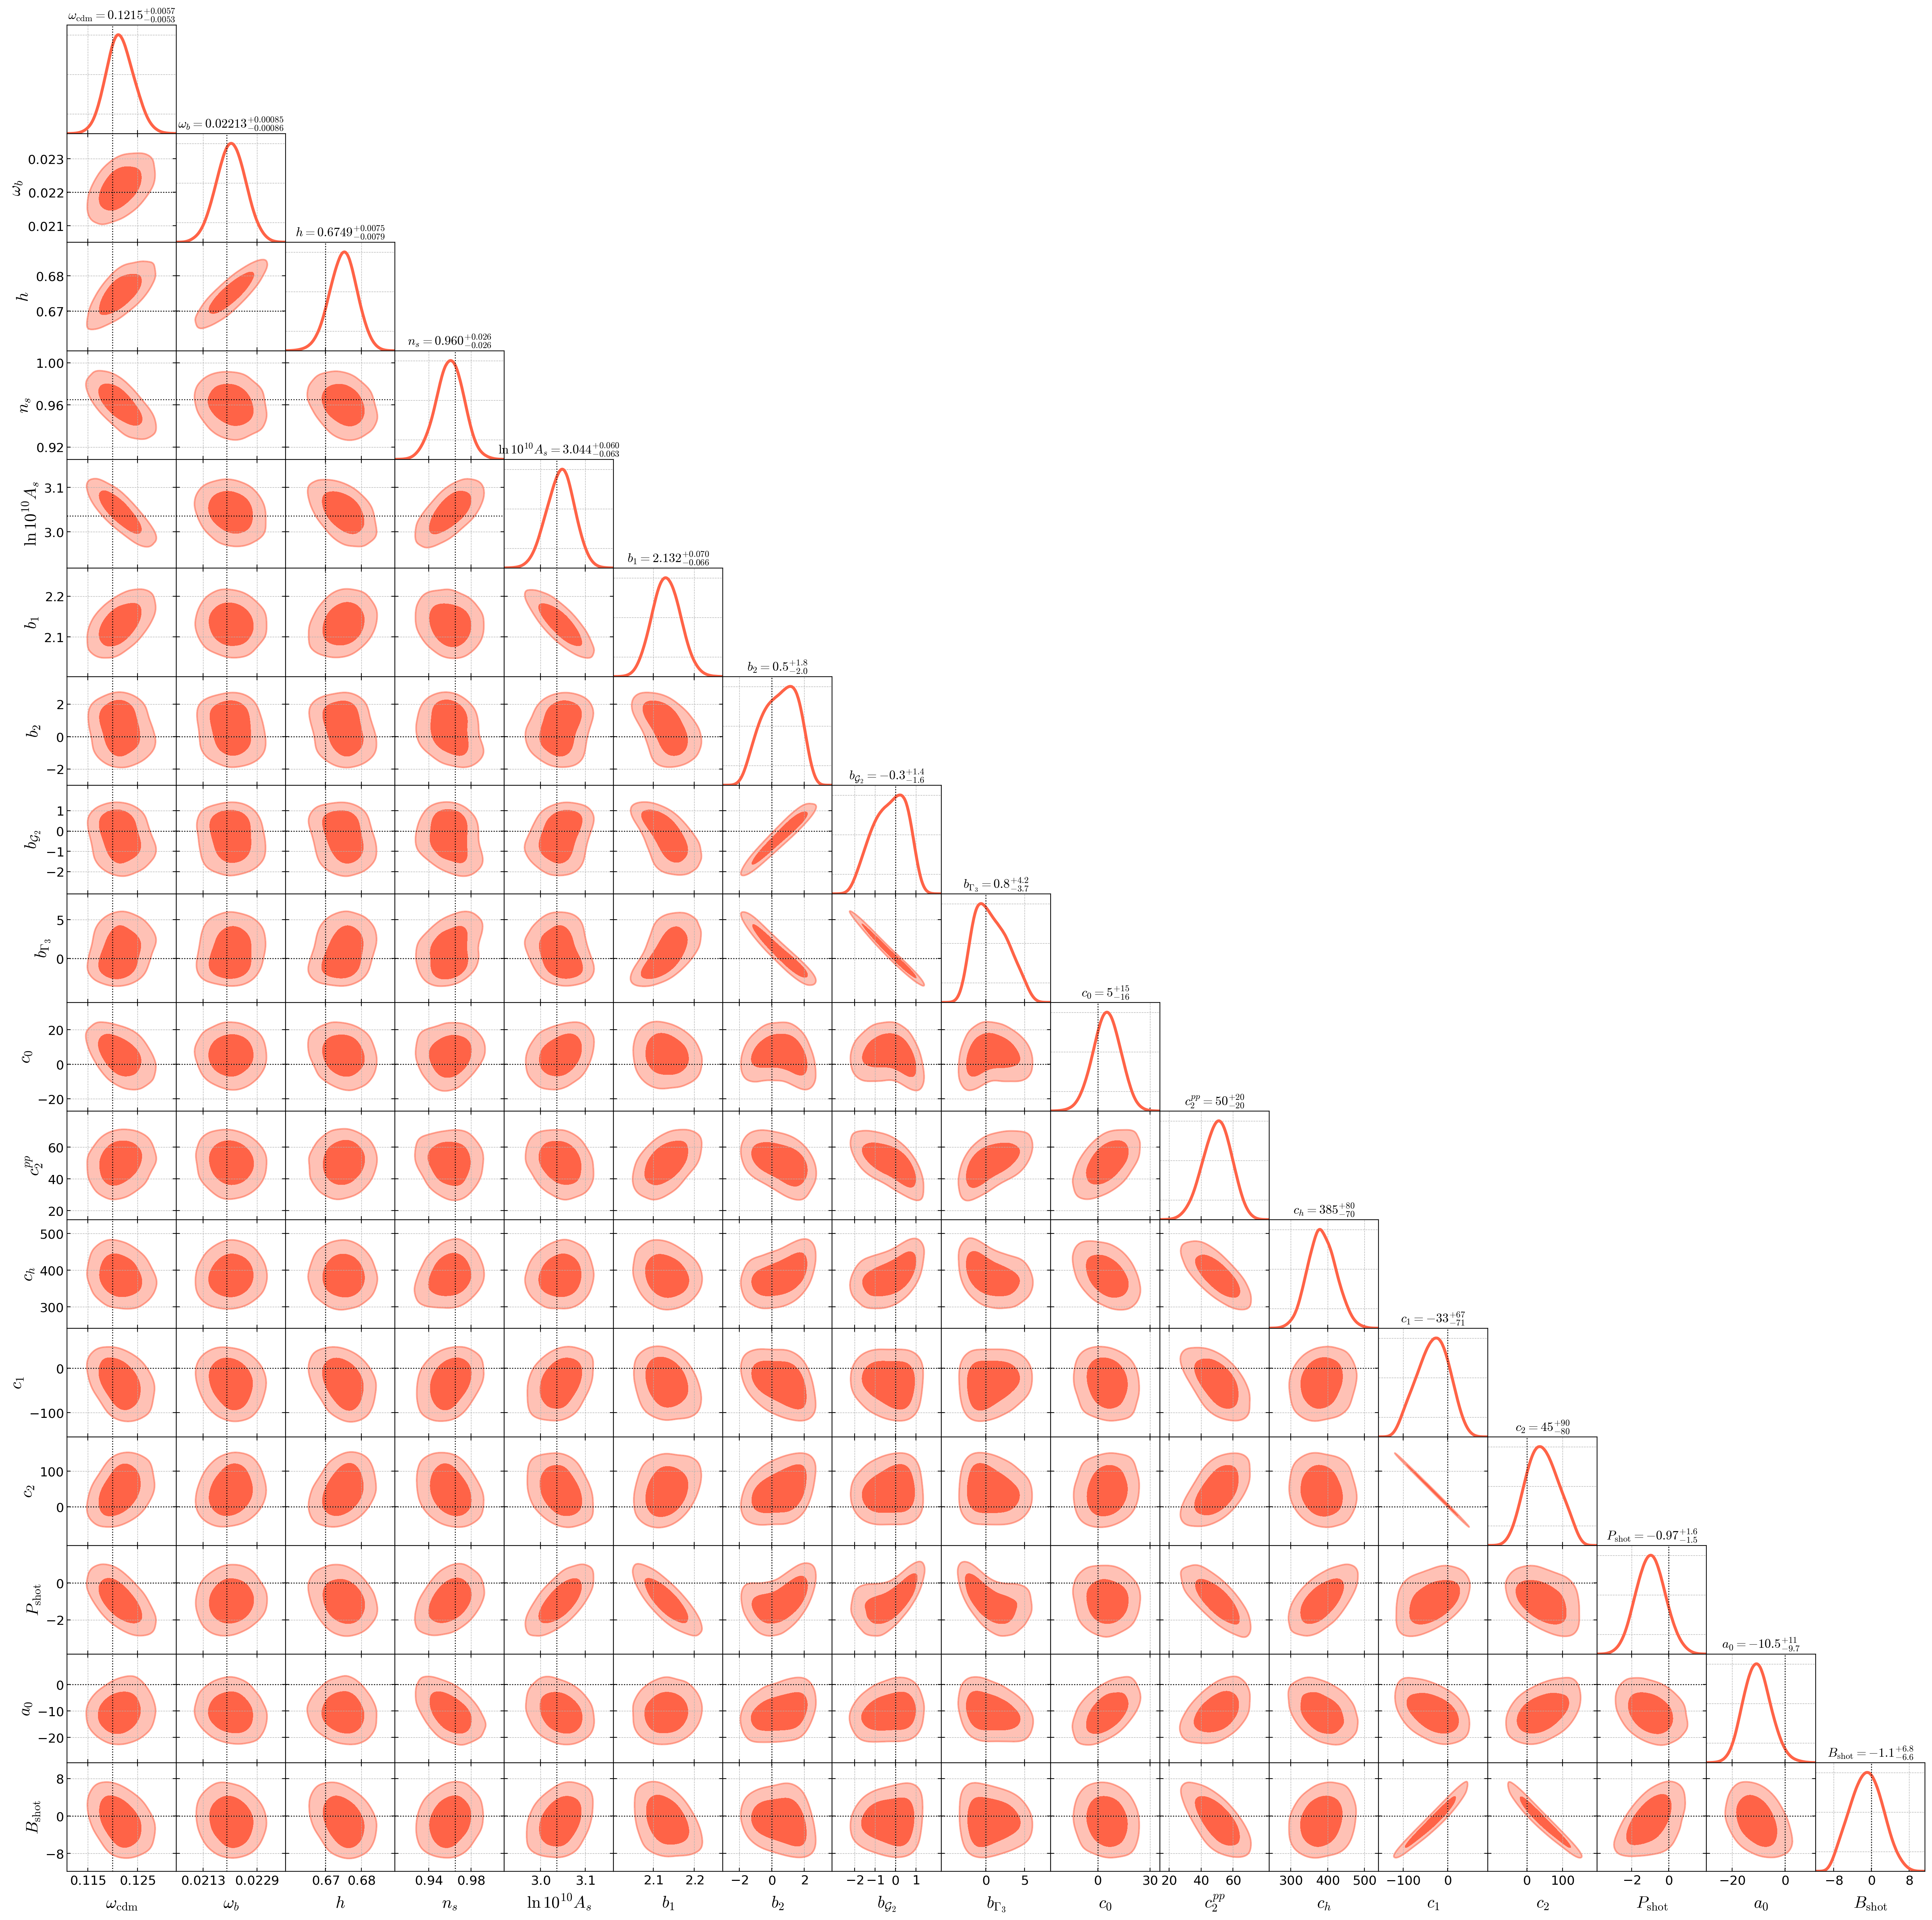

In [17]:
g = plots.get_subplot_plotter()

samples1 = MCSamples(samples=chain['samples'], weights=chain['weights'], names=names, labels=labels)

g.settings.legend_fontsize = 22
g.settings.axes_fontsize   = 16
g.settings.axes_labelsize  = 20

g.triangle_plot([samples1], filled=True, 
                contour_colors=['tomato','cornflowerblue','orange'],
                   contour_lws = [3], contour_ls=['-'],
                       markers=fiducial, marker_args={'lw': 1, 'ls':':','c':'k'},
                        title_limit = 2
               )

In [31]:
def get_samples(SAMPLE,cosmo_only=False,bias_only=False,alej_comp=False,ns=False):
    samples_cdm = SAMPLE['samples'][:,0]
    samples_b   = SAMPLE['samples'][:,1]
    samples_h   = SAMPLE['samples'][:,2]
    if ns:
        samples_As  = SAMPLE['samples'][:,4]
        samples_b1  = SAMPLE['samples'][:,5]
        samples_b2  = SAMPLE['samples'][:,6]
        samples_bG2  = SAMPLE['samples'][:,7]
    else:
        samples_As  = SAMPLE['samples'][:,3]
        samples_b1  = SAMPLE['samples'][:,4]
        samples_b2  = SAMPLE['samples'][:,5]
        samples_bG2  = SAMPLE['samples'][:,6]
    
    samples_Omega_m = (samples_cdm+samples_b)/samples_h**2.0
    samples_omega_m = (samples_cdm+samples_b)

    if cosmo_only:
        resp = np.column_stack((samples_h,samples_Omega_m,samples_As))
    elif bias_only:
        resp = np.column_stack((samples_b1,samples_b2,samples_bG2))
    elif alej_comp:
        resp = np.column_stack((samples_h,samples_Omega_m,samples_As,samples_b1,samples_b2))
    else:
        resp = np.column_stack((samples_h,samples_omega_m,samples_As))
    
    return resp

In [32]:
labels_Om = ['h',
             '\\Omega_{\\rm m}',
             '\\ln(10^{10}A_s)',
             'b_1',
             'b_2']

names_Om = ['h',
            'Omega_m',
            'ln10^{10}A_s',
            'b1',
            'b2'
           ]

fiducial_Om = [0.6736, (fiducial[0]+fiducial[1])/fiducial[2]**2.0, 3.036, 2.2]

labels_cosmo = ['h',
             '\\Omega_{\\rm m}',
             '\\ln(10^{10}A_s)']

names_cosmo = ['h',
            'Omega_m',
            'ln10^{10}A_s']

fiducial_cosmo = [0.6736, (fiducial[0]+fiducial[1])/fiducial[2]**2.0, 3.036]

labels_bias = [
             'b_1',
             'b_2',
             'b_{\mathcal{G}_2}']

names_bias = [
            'b1',
            'b2',
            'bG2'
           ]

fiducial_bias = [2.2, 0,0]

In [38]:
chain2 = np.load('/Users/austerlitz/TripoSH-Factory/my_project/results/nautilus/LRG/p0p2b0b2_noresc_kmax1_results.npy',allow_pickle=True).item()

chain3 = np.load('/Users/austerlitz/Desktop/test/TripoSH-Fitting-v2/p0p2b0b2_noresc.npy',allow_pickle=True).item()

Removed no burn in
Removed no burn in
Removed no burn in


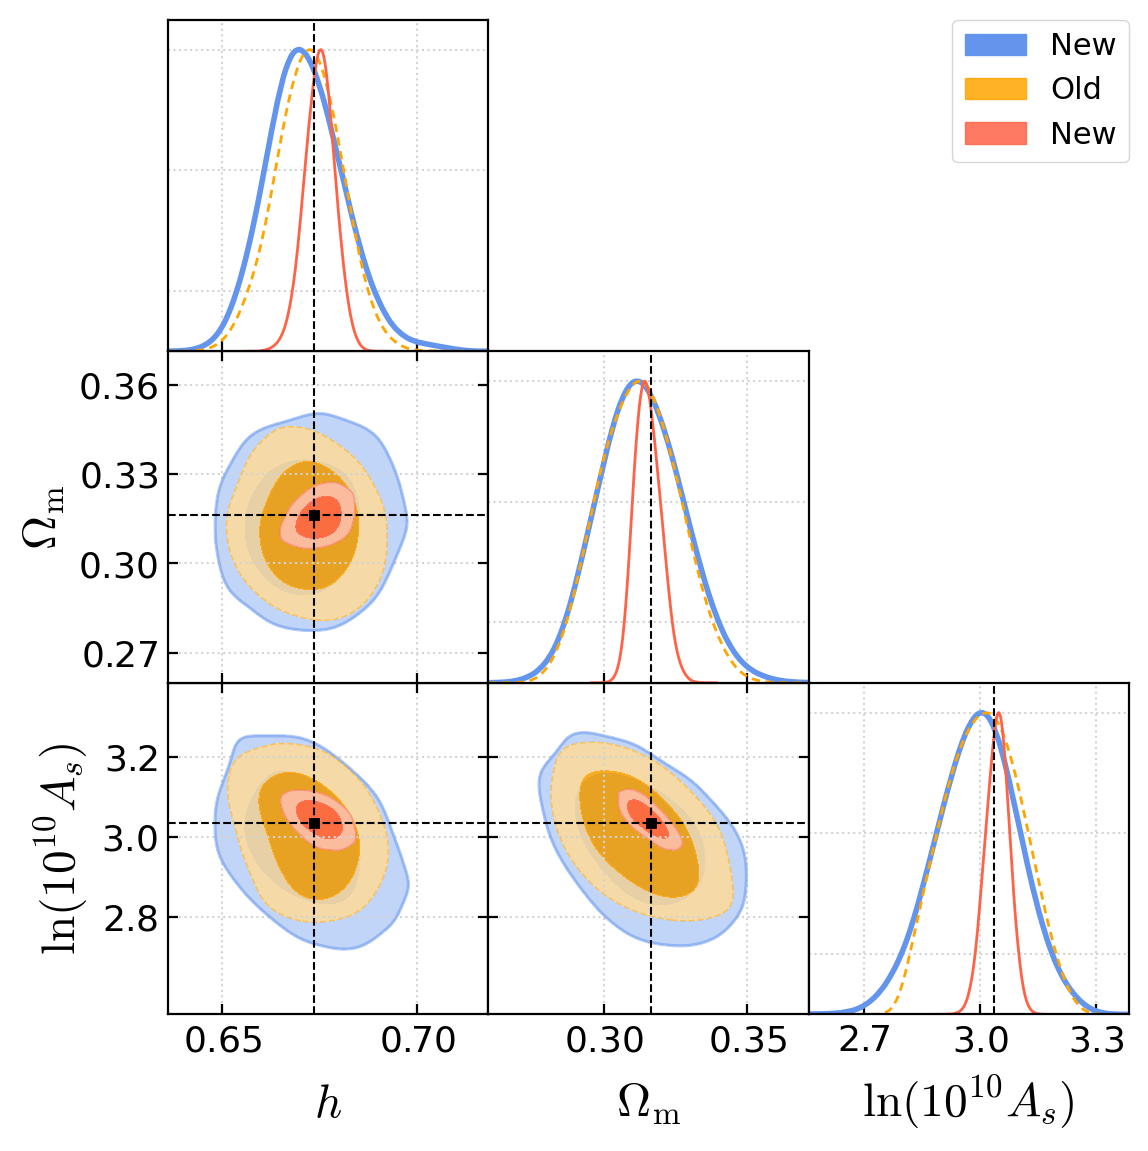

In [42]:
g = plots.get_subplot_plotter()

samples1 = MCSamples(samples=get_samples(chain,cosmo_only=True,ns=True), weights=chain['weights'], 
                    labels=labels_cosmo, names=names_cosmo,
                   )
samples2 = MCSamples(samples=get_samples(chain2,cosmo_only=True), weights=np.exp(chain2['log_w']), 
                    labels=labels_cosmo, names=names_cosmo,
                   )
samples3 = MCSamples(samples=get_samples(chain3,cosmo_only=True,ns=True), weights=chain3['weights'], 
                    labels=labels_cosmo, names=names_cosmo,
                   )

g.settings.legend_fontsize = 14
g.settings.axes_fontsize   = 16
g.settings.axes_labelsize  = 20

g.triangle_plot([samples2,samples3,samples1], filled=True, 
                   colors=['cornflowerblue','orange','tomato'],contour_colors=['cornflowerblue','orange','tomato'],
                    contour_lws = [2,1,1], contour_ls=['-','--','-'],
                legend_labels=[r'Old',
                               r'New',
                               r'New'])
for i in range(3):
    g.subplots[i,i].axvline(fiducial_cosmo[i], color='k', ls='--', lw=0.75)
    g.subplots[i,i].grid(ls=':',lw=0.75,c='lightgrey')

for yi in range(3):
    for xi in range(yi):
        g.subplots[yi,xi].plot(fiducial_cosmo[xi], fiducial_cosmo[yi], 'sk', markersize=3)
        g.subplots[yi,xi].axvline(fiducial_cosmo[xi], color='k', ls='--', lw=0.75)
        g.subplots[yi,xi].axhline(fiducial_cosmo[yi], color='k', ls='--', lw=0.75)
        g.subplots[yi,xi].grid(ls=':',lw=0.75,c='lightgrey')

#pl.savefig('/Users/austerlitz/TripoSH-Factory/my_project/results/nautilus/QSO/pb_kmax_phmean_cosmo.png',dpi=300,bbox_inches='tight')

Removed no burn in
Removed no burn in
Removed no burn in


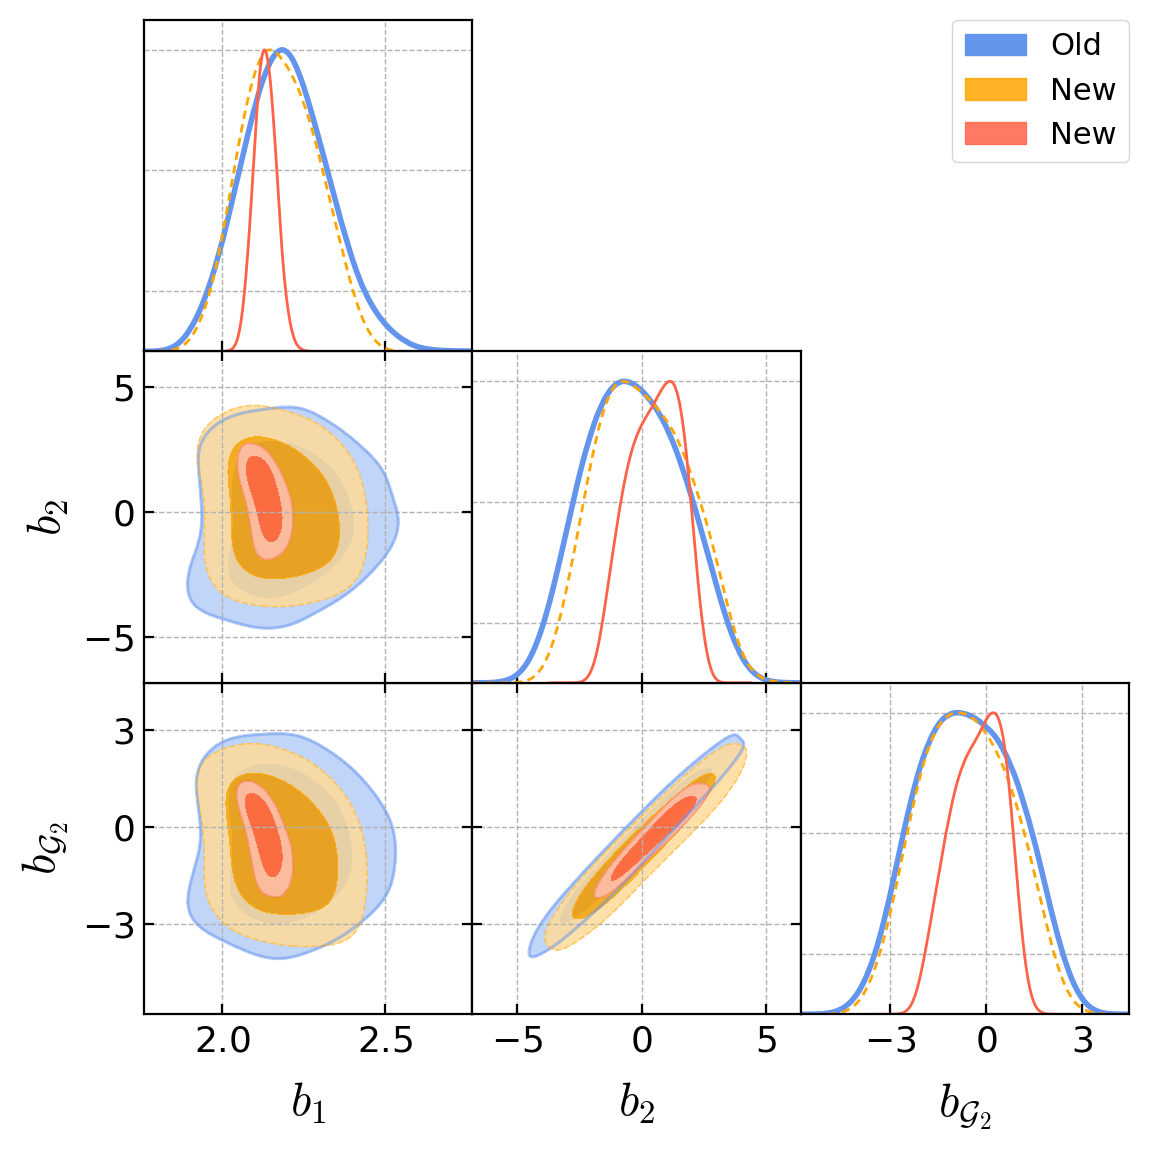

In [44]:
g = plots.get_subplot_plotter()

samples1 = MCSamples(samples=get_samples(chain,bias_only=True,ns=True), weights=chain['weights'], 
                    labels=labels_bias, names=names_bias,
                   )
samples2 = MCSamples(samples=get_samples(chain2,bias_only=True), weights=np.exp(chain2['log_w']), 
                    labels=labels_bias, names=names_bias,
                   )
samples3 = MCSamples(samples=get_samples(chain3,bias_only=True,ns=True), weights=chain3['weights'], 
                    labels=labels_bias, names=names_bias,
                   )

g.settings.legend_fontsize = 14
g.settings.axes_fontsize   = 16
g.settings.axes_labelsize  = 20

g.triangle_plot([samples2,samples3,samples1], filled=True, 
                   colors=['cornflowerblue','orange','tomato'],contour_colors=['cornflowerblue','orange','tomato'],
                    contour_lws = [2,1,1], contour_ls=['-','--','-'],
                legend_labels=[r'Old',
                               r'New',
                               r'New'
                               ])